# 03 - EDA

## PB-04: Análisis de calidad de datos

En esta notebook se realiza una revisión inicial de calidad del dataset, enfocada en:

- valores nulos
- tipos de datos
- filas duplicadas
- detección exploratoria de outliers

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/raw/dataset.csv")
df.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


## Dimensiones del dataset

Se verifica el tamaño general del dataset antes de evaluar su calidad.

In [3]:
df.shape

(11055, 31)

## Tipos de datos

Se revisa el tipo de dato de cada variable para identificar consistencia en la estructura del dataset.

In [4]:
df.dtypes

having_IP_Address              int64
URL_Length                     int64
Shortining_Service             int64
having_At_Symbol               int64
double_slash_redirecting       int64
Prefix_Suffix                  int64
having_Sub_Domain              int64
SSLfinal_State                 int64
Domain_registeration_length    int64
Favicon                        int64
port                           int64
HTTPS_token                    int64
Request_URL                    int64
URL_of_Anchor                  int64
Links_in_tags                  int64
SFH                            int64
Submitting_to_email            int64
Abnormal_URL                   int64
Redirect                       int64
on_mouseover                   int64
RightClick                     int64
popUpWidnow                    int64
Iframe                         int64
age_of_domain                  int64
DNSRecord                      int64
web_traffic                    int64
Page_Rank                      int64
G

## Resumen de tipos de datos

Se resume la cantidad de variables por tipo de dato.

In [5]:
df.dtypes.value_counts()

int64    31
Name: count, dtype: int64

## Valores nulos

Se cuantifican los valores faltantes por columna y su porcentaje respecto al total de registros.

In [6]:
missing_summary = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values("null_count", ascending=False)

missing_summary

,null_count,null_pct
having_IP_Address,0,0.0
URL_Length,0,0.0
Shortining_Service,0,0.0
having_At_Symbol,0,0.0
double_slash_redirecting,0,0.0
Prefix_Suffix,0,0.0
having_Sub_Domain,0,0.0
SSLfinal_State,0,0.0
Domain_registeration_length,0,0.0
Favicon,0,0.0


## Filas duplicadas

Se verifica si existen registros duplicados exactos dentro del dataset.

In [7]:
df.duplicated().sum()

np.int64(5206)

## Variables numéricas

Se identifican las columnas numéricas para evaluar de forma exploratoria la presencia de posibles outliers.

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols

['having_IP_Address',
 'URL_Length',
 'Shortining_Service',
 'having_At_Symbol',
 'double_slash_redirecting',
 'Prefix_Suffix',
 'having_Sub_Domain',
 'SSLfinal_State',
 'Domain_registeration_length',
 'Favicon',
 'port',
 'HTTPS_token',
 'Request_URL',
 'URL_of_Anchor',
 'Links_in_tags',
 'SFH',
 'Submitting_to_email',
 'Abnormal_URL',
 'Redirect',
 'on_mouseover',
 'RightClick',
 'popUpWidnow',
 'Iframe',
 'age_of_domain',
 'DNSRecord',
 'web_traffic',
 'Page_Rank',
 'Google_Index',
 'Links_pointing_to_page',
 'Statistical_report',
 'Result']

## Detección exploratoria de outliers (IQR)

Se aplica el criterio de rango intercuartílico (IQR) sobre las variables numéricas para estimar la cantidad de observaciones fuera del rango esperado.

Nota: este análisis es exploratorio. En datasets con variables discretizadas o codificadas, la interpretación de outliers debe hacerse con cautela.

In [9]:
outlier_counts = {}

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_summary = pd.DataFrame.from_dict(
    outlier_counts, orient="index", columns=["outlier_count"]
).sort_values("outlier_count", ascending=False)

outlier_summary

,outlier_count
SFH,2615
popUpWidnow,2137
URL_Length,2095
Favicon,2053
Submitting_to_email,2014
HTTPS_token,1796
having_At_Symbol,1655
Abnormal_URL,1629
Statistical_report,1550
Google_Index,1539


## Resumen de calidad de datos

En esta etapa se revisó la calidad básica del dataset mediante:

- verificación de tipos de datos
- conteo de valores nulos
- detección de filas duplicadas
- estimación exploratoria de outliers

Esta sección corresponde al backlog item **PB-04: Análisis de calidad de datos**.

# PB-05: Estadísticas descriptivas y visualizaciones

En esta sección se amplía el análisis exploratorio del dataset con:

- estadísticas descriptivas
- distribución del target
- balance de clases
- visualizaciones base
- correlación de variables con la variable objetivo

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

## Estadísticas descriptivas

Se resumen las principales medidas descriptivas de las variables numéricas del dataset.

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
having_IP_Address,11055.0,0.313795,0.949534,-1.0,-1.0,1.0,1.0,1.0
URL_Length,11055.0,-0.633198,0.766095,-1.0,-1.0,-1.0,-1.0,1.0
Shortining_Service,11055.0,0.738761,0.673998,-1.0,1.0,1.0,1.0,1.0
having_At_Symbol,11055.0,0.700588,0.713598,-1.0,1.0,1.0,1.0,1.0
double_slash_redirecting,11055.0,0.741474,0.671011,-1.0,1.0,1.0,1.0,1.0
Prefix_Suffix,11055.0,-0.734962,0.678139,-1.0,-1.0,-1.0,-1.0,1.0
having_Sub_Domain,11055.0,0.063953,0.817518,-1.0,-1.0,0.0,1.0,1.0
SSLfinal_State,11055.0,0.250927,0.911892,-1.0,-1.0,1.0,1.0,1.0
Domain_registeration_length,11055.0,-0.336771,0.941629,-1.0,-1.0,-1.0,1.0,1.0
Favicon,11055.0,0.628584,0.777777,-1.0,1.0,1.0,1.0,1.0


## Distribución de la variable objetivo

Se analiza la frecuencia de cada clase de la variable `Result`.

In [12]:
df["Result"].value_counts().sort_index()

Result
-1    4898
 1    6157
Name: count, dtype: int64

## Balance de clases

Se calcula el porcentaje que representa cada clase dentro del total del dataset.

In [13]:
(df["Result"].value_counts(normalize=True).sort_index() * 100).round(2)

Result
-1    44.31
 1    55.69
Name: proportion, dtype: float64

## Visualización del target

Se representa gráficamente la distribución de la variable objetivo para verificar si existe desbalance entre clases.

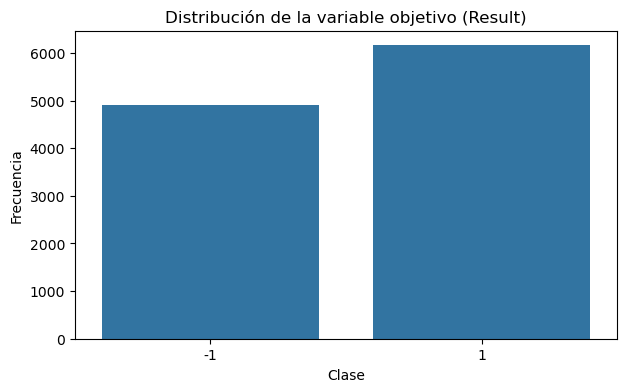

In [14]:
plt.figure(figsize=(7,4))
sns.countplot(x="Result", data=df)
plt.title("Distribución de la variable objetivo (Result)")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.show()

## Visualización de variables seleccionadas

Se exploran algunas variables del dataset para observar su comportamiento general.

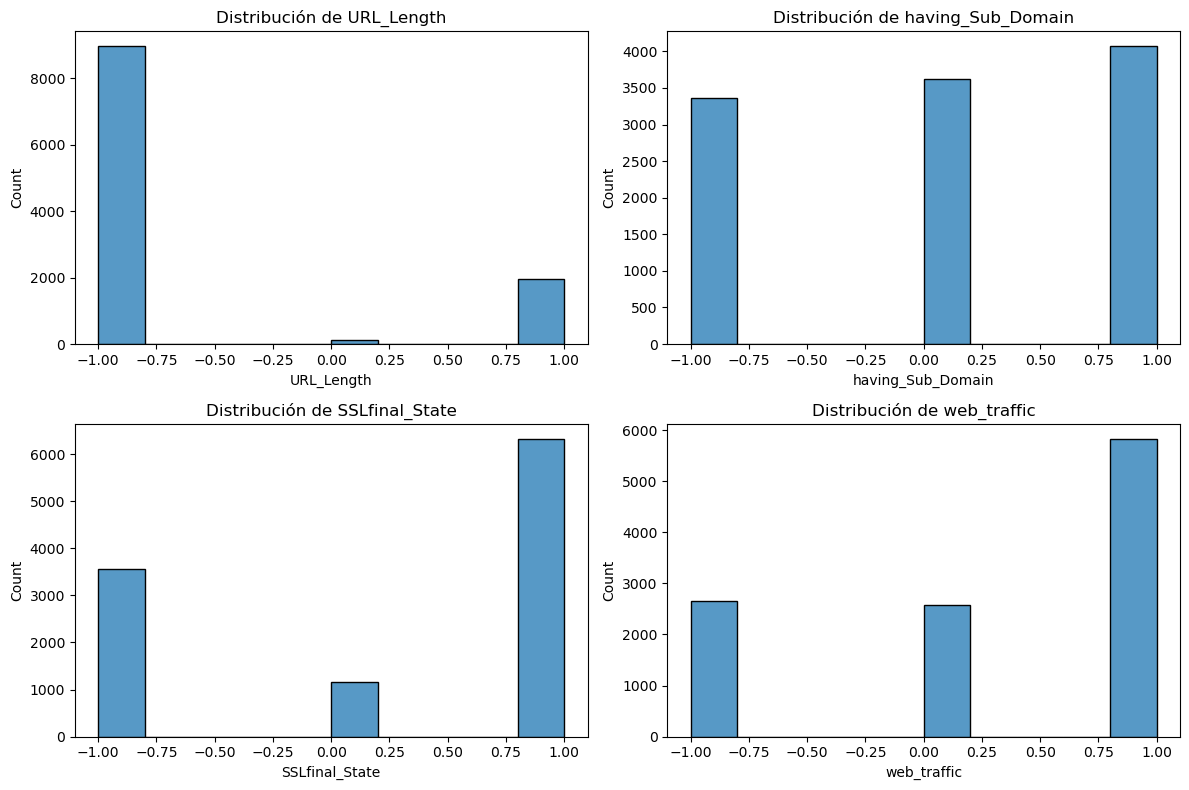

In [15]:
selected_cols = ["URL_Length", "having_Sub_Domain", "SSLfinal_State", "web_traffic"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(selected_cols):
    sns.histplot(df[col], ax=axes[i], bins=10)
    axes[i].set_title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

## Correlación de variables con el target

Se calcula la correlación entre las variables numéricas y la variable objetivo `Result`.

In [16]:
corr_with_target = df.corr(numeric_only=True)["Result"].sort_values(ascending=False)
corr_with_target

Result                         1.000000
SSLfinal_State                 0.714741
URL_of_Anchor                  0.692935
Prefix_Suffix                  0.348606
web_traffic                    0.346103
having_Sub_Domain              0.298323
Request_URL                    0.253372
Links_in_tags                  0.248229
SFH                            0.221419
Google_Index                   0.128950
age_of_domain                  0.121496
Page_Rank                      0.104645
having_IP_Address              0.094160
Statistical_report             0.079857
DNSRecord                      0.075718
URL_Length                     0.057430
having_At_Symbol               0.052948
on_mouseover                   0.041838
port                           0.036419
Links_pointing_to_page         0.032574
Submitting_to_email            0.018249
RightClick                     0.012653
popUpWidnow                    0.000086
Favicon                       -0.000280
Iframe                        -0.003394


## Variables más relacionadas con el target

Se visualizan las variables con mayor correlación positiva o negativa respecto a `Result`.

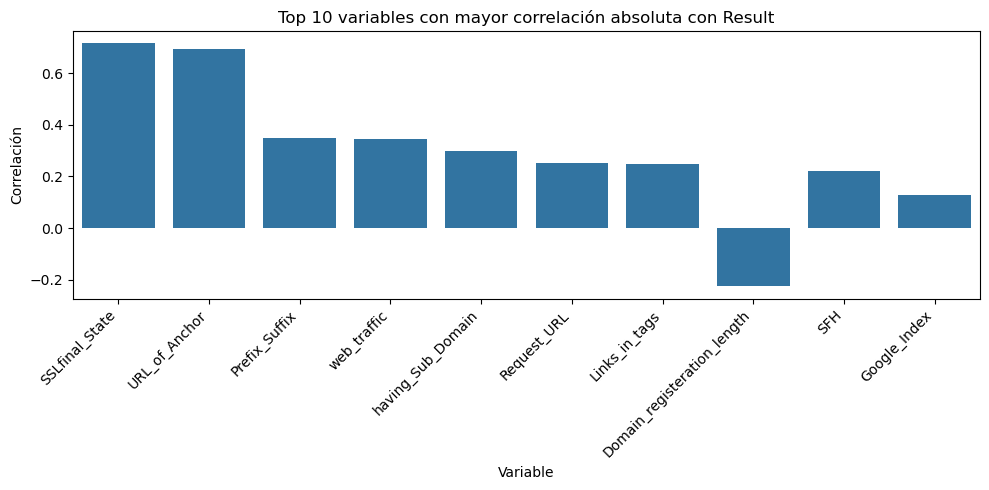

In [17]:
top_corr = corr_with_target.drop("Result").sort_values(key=lambda s: s.abs(), ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_corr.index, y=top_corr.values)
plt.title("Top 10 variables con mayor correlación absoluta con Result")
plt.xlabel("Variable")
plt.ylabel("Correlación")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Heatmap de correlación

Se construye un mapa de calor con la matriz de correlación de las variables numéricas.

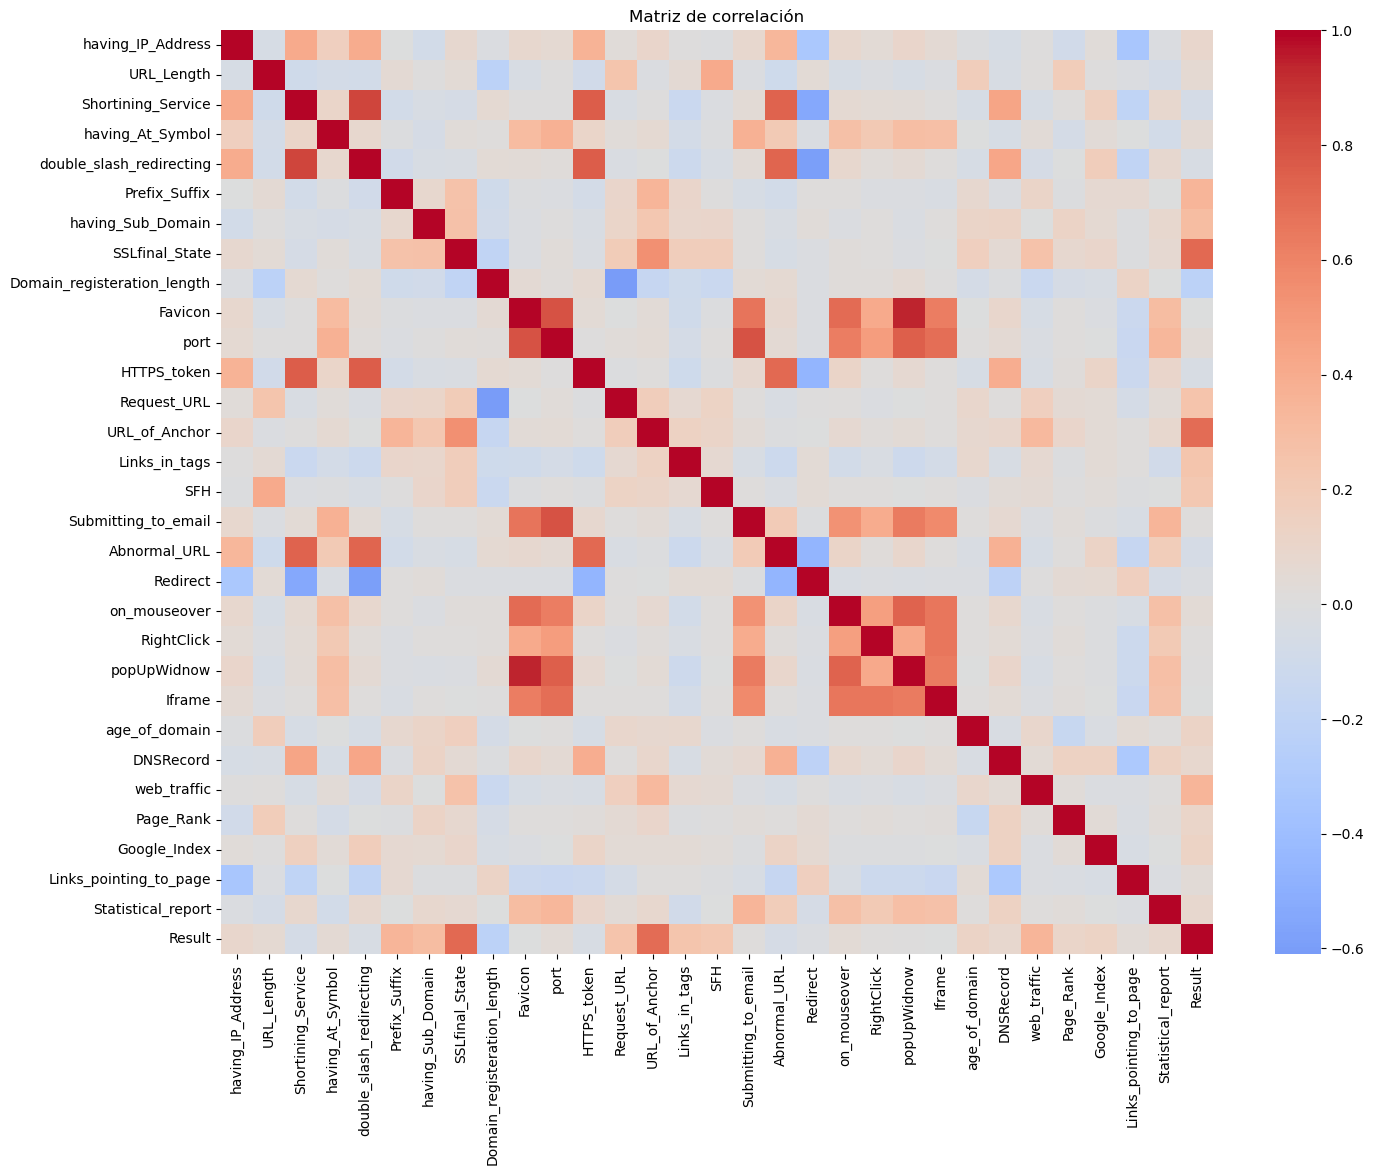

In [18]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

## Resumen de PB-05

En esta sección se incorporaron:

- estadísticas descriptivas
- análisis de la distribución del target
- evaluación del balance de clases
- visualizaciones exploratorias
- correlación de variables con la variable objetivo

Esta sección corresponde al backlog item **PB-05: Estadísticas y visualizaciones**.